In [93]:
import pandas as pd
import numpy as np
from pathlib import Path
import re
import matplotlib.pyplot as plt

SKEW_FRACTION=0.8
SKEW_PARTITION=0

ROOT = Path("../results/20260223_235807_skew/consumer/")
#ROOT = Path("../results/20260223_052810/consumer/")  
files = sorted(ROOT.glob("consumer-sts-*_metrics/per_message_latency_run-*_consumer-sts-*.csv"))

print("Found per-message files:", len(files))
for f in files[:10]:
    print(" -", f.name)

def read_one(fpath: Path) -> pd.DataFrame:
    df = pd.read_csv(fpath)

    # Your per-message schema should include these
    needed = {"recv_ts","producer_ts","e2e_ms","topic","partition","offset","producer_pod","index"}
    missing = needed - set(df.columns)
    if missing:
        raise ValueError(f"{fpath.name} missing columns: {missing}")

    m = re.search(r"(consumer-sts-\d+)", fpath.name)
    df["consumer_pod"] = m.group(1) if m else "unknown"

    # types
    df["recv_ts"] = pd.to_numeric(df["recv_ts"], errors="coerce")
    df["producer_ts"] = pd.to_numeric(df["producer_ts"], errors="coerce")
    df["e2e_ms"] = pd.to_numeric(df["e2e_ms"], errors="coerce")
    df["partition"] = pd.to_numeric(df["partition"], errors="coerce").astype("Int64")
    df["offset"] = pd.to_numeric(df["offset"], errors="coerce").astype("Int64")

    df = df.dropna(subset=["recv_ts","producer_ts","e2e_ms"])
    return df

lat = pd.concat([read_one(f) for f in files], ignore_index=True)
print("Total sampled messages:", len(lat), "pods:", lat["consumer_pod"].nunique())

lat

Found per-message files: 8
 - per_message_latency_run-20260223-232853_consumer-sts-0.csv
 - per_message_latency_run-20260223-232853_consumer-sts-1.csv
 - per_message_latency_run-20260223-232853_consumer-sts-2.csv
 - per_message_latency_run-20260223-232853_consumer-sts-3.csv
 - per_message_latency_run-20260223-232853_consumer-sts-4.csv
 - per_message_latency_run-20260223-232853_consumer-sts-5.csv
 - per_message_latency_run-20260223-232853_consumer-sts-6.csv
 - per_message_latency_run-20260223-232853_consumer-sts-7.csv
Total sampled messages: 2342 pods: 8


,recv_ts,producer_ts,e2e_ms,topic,partition,offset,producer_pod,index,consumer_pod
0,1.771915e+09,1.771915e+09,15.899420,B0-R100-20260223-232853_0,22,14,producer-sts-0,1535,consumer-sts-0
1,1.771915e+09,1.771915e+09,200.753450,B0-R100-20260223-232853_0,16,37,producer-sts-2,2761,consumer-sts-0
2,1.771915e+09,1.771915e+09,16.464710,B0-R100-20260223-232853_0,17,28,producer-sts-0,3297,consumer-sts-0
3,1.771915e+09,1.771915e+09,16.894341,B0-R100-20260223-232853_0,23,71,producer-sts-1,6456,consumer-sts-0
4,1.771915e+09,1.771915e+09,595.428228,B0-R100-20260223-232853_0,18,72,producer-sts-2,7222,consumer-sts-0
...,...,...,...,...,...,...,...,...,...
2337,1.771916e+09,1.771916e+09,22.624969,B0-R100-20260223-232853_0,34,1486,producer-sts-1,149505,consumer-sts-7
2338,1.771916e+09,1.771916e+09,12.413740,B0-R100-20260223-232853_0,33,1518,producer-sts-2,151816,consumer-sts-7
2339,1.771916e+09,1.771916e+09,81.597805,B0-R100-20260223-232853_0,33,1561,producer-sts-1,156901,consumer-sts-7
2340,1.771916e+09,1.771916e+09,29.156685,B0-R100-20260223-232853_0,36,1630,producer-sts-1,157441,consumer-sts-7


In [94]:
pod_summary = (
    lat.groupby("consumer_pod", as_index=False)
       .agg(
           n=("e2e_ms", "size"),
           p50_ms=("e2e_ms", lambda x: float(x.quantile(0.50))),
           p95_ms=("e2e_ms", lambda x: float(x.quantile(0.95))),
           p99_ms=("e2e_ms", lambda x: float(x.quantile(0.99))),  
           max_ms=("e2e_ms", "max"),
       )
       .sort_values("p99_ms", ascending=False)
)

pod_summary


,consumer_pod,n,p50_ms,p95_ms,p99_ms,max_ms
3,consumer-sts-3,1532,471111.101985,952078.547871,985594.857223,994523.503065
0,consumer-sts-0,140,16.407371,684.338939,1839.978235,2183.182955
7,consumer-sts-7,102,16.940117,830.529976,1679.489257,1799.374580
5,consumer-sts-5,107,16.612291,1144.692850,1502.528992,1544.993639
1,consumer-sts-1,117,16.943693,895.298862,1391.567898,1455.268621
4,consumer-sts-4,125,18.023729,621.738815,1319.611626,1518.801928
6,consumer-sts-6,117,16.652584,661.760330,1198.945246,1666.862249
2,consumer-sts-2,102,17.280579,820.880497,1106.051748,1848.529100


In [95]:
s = lat["e2e_ms"].to_numpy()

cluster_summary = {
    "n": len(s),
    "p50_ms": np.quantile(s, 0.50),
    "p95_ms": np.quantile(s, 0.95),
    "p99_ms": np.quantile(s, 0.99),
    #"p999_ms": np.quantile(s, 0.999) if len(arr) >= 1000 else np.nan,
    "max_ms": float(np.max(s)),
}
cluster_summary


{'n': 2342,
 'p50_ms': 172233.00063610077,
 'p95_ms': 926763.5463118553,
 'p99_ms': 982790.9035849574,
 'max_ms': 994523.5030651093}

In [96]:
BUCKET_SEC = 30
t0 = lat["recv_ts"].min()
lat["t_bucket"] = (np.floor((lat["recv_ts"] - t0) / BUCKET_SEC) * BUCKET_SEC).astype(int)

# Tail fractions at multiple thresholds (you can tune these)
thresholds = [500, 700, 800, 900, 1000, 1500]

def bucket_metrics(g):
    arr = g["e2e_ms"].to_numpy()
    out = {
        "n": len(arr),
        "true_p95_ms": np.quantile(arr, 0.95),
        "true_p99_ms": np.quantile(arr, 0.99),
        "true_p999_ms": np.quantile(arr, 0.999) if len(arr) >= 1000 else np.nan,
        "max_ms": float(np.max(arr)),
    }
    for thr in thresholds:
        out[f"tail_frac_gt_{thr}"] = float(np.mean(arr > thr))
    return pd.Series(out)

bucket = (lat.groupby("t_bucket")
          .apply(bucket_metrics)
          .reset_index()
          .sort_values("t_bucket"))

#bucket.head()


In [97]:
from pathlib import Path
path = "../results/20260223_232437_skew/"
run_id = Path(path).resolve().name

print(run_id)

20260223_232437_skew


FileNotFoundError: [Errno 2] No such file or directory: 'analysis_out/20260223_232437_skew/per-message/Per-msg-true p99, max by 30s bucket_20260223_232437_skew.pdf'

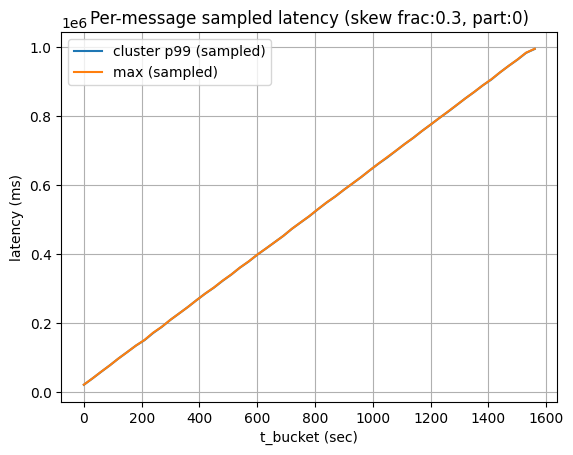

In [98]:
plt.figure()
plt.plot(bucket["t_bucket"], bucket["true_p99_ms"], label="cluster p99 (sampled)")
plt.plot(bucket["t_bucket"], bucket["max_ms"], label="max (sampled)")
plt.xlabel("t_bucket (sec)")
plt.ylabel("latency (ms)")
plt.title(f"Per-message sampled latency (skew frac:0.3, part:0)")
plt.grid(True)
plt.legend()
plt.savefig(f"analysis_out/{run_id}/per-message/Per-msg-true p99, max by 30s bucket_{run_id}.pdf", bbox_inches="tight")
plt.show()

plt.figure()
# for thr in thresholds:
#     plt.plot(bucket["t_bucket"], bucket[f"tail_frac_gt_{thr}"], label=f"P(lat>{thr}ms)")
# plt.xlabel("t_bucket (sec)")
# plt.ylabel("fraction")
# plt.title("Tail fractions by threshold (skew)")
# plt.grid(True)
# plt.legend()
# plt.savefig(f"analysis_out/{run_id}/per-message/Tail fractions by threshold (sampled)_{run_id}.pdf", bbox_inches="tight")
# plt.show()


In [90]:
# Worst buckets by p99 and by max
worst_by_p99 = bucket.sort_values("true_p99_ms", ascending=False).head(10)
worst_by_max = bucket.sort_values("max_ms", ascending=False).head(10)

worst_by_p99, worst_by_max
worst_bucket = int(worst_by_max.iloc[0]["t_bucket"])

tmp = lat[lat["t_bucket"] == worst_bucket].sort_values("e2e_ms", ascending=False).head(30)

tmp[["consumer_pod","e2e_ms","recv_ts","producer_ts","topic","partition","offset","producer_pod","index"]]
tmp.to_csv(f"./analysis_out/{run_id}/per-message/worst_buckets_{run_id}.csv", index=False)


OSError: Cannot save file into a non-existent directory: 'analysis_out/20260223_232437_skew/per-message'

In [82]:
PER_POD_METRICS = "analysis_out/20260223_005626/per_pod_merged_20260223_005626.csv"  
per_pod = pd.read_csv(PER_POD_METRICS)


print(per_pod.columns)

cluster_lag = (per_pod.groupby("t_bucket")
               .agg(window_total=("window_total","sum"),
                    window_viol=("window_viol","sum"),
                    total_lag=("total_lag","sum"),
                    max_lag=("max_lag","max"),
                    lag_skew_ratio=("lag_skew_ratio","max"))
               .reset_index())

merged = bucket.merge(cluster_lag, on="t_bucket", how="left")

merged[["t_bucket","true_p99_ms","max_ms","max_lag","total_lag","lag_skew_ratio"]].head()

cols = ["true_p99_ms","max_ms","max_lag","total_lag","lag_skew_ratio"]
corr = merged[cols].corr(numeric_only=True)
corr


Index(['pod', 'traffic_mode', 'topics', 'window_total', 'window_viol',
       'msg_rate_window', 'lat_window_seconds', 'lat_count_window',
       'lat_p95_ms', 'lat_p99_ms', 'cpu_percent', 'mem_percent', 'uptime_sec',
       'total_lag', 'max_lag', 'lag_skew_ratio', 'consumed_total', 'file',
       'viol_rate', 't_bucket'],
      dtype='object')


,true_p99_ms,max_ms,max_lag,total_lag,lag_skew_ratio
true_p99_ms,1.000000,0.999878,0.002299,0.157440,-0.258995
max_ms,0.999878,1.000000,0.004113,0.157802,-0.258418
max_lag,0.002299,0.004113,1.000000,0.408170,0.138950
total_lag,0.157440,0.157802,0.408170,1.000000,-0.341399
lag_skew_ratio,-0.258995,-0.258418,0.138950,-0.341399,1.000000


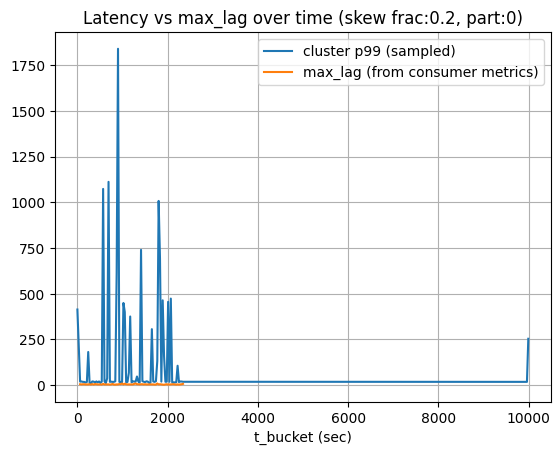

In [83]:
plt.figure()
plt.plot(merged["t_bucket"], merged["true_p99_ms"], label="cluster p99 (sampled)")
plt.plot(merged["t_bucket"], merged["max_lag"], label="max_lag (from consumer metrics)")
plt.xlabel("t_bucket (sec)")
plt.title("Latency vs max_lag over time (skew frac:0.2, part:0)")
plt.grid(True)
plt.legend()
plt.savefig(f"analysis_out/{run_id}/per-message/Latency vs max_lag over time_{run_id}.pdf", bbox_inches="tight")
plt.show()
